# Aufgaben: Generatives Lernen

### Aufgabe 2: Implementierung (optional, ggf. längerfristig)

*Implementieren Sie ein GAN mit PyTorch. Verwenden Sie dafür einen beliebigen bildlichen Datensatz, bspw. MNIST.*


In [ ]:
# Importieren der Biblotheken
# Zum Beispiel
import random

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# Sicherstellen, dass PyTorch die GPU verwenden kann, falls verfügbar
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Verwende Gerät: {device}")


# Um die Ergebnisse reproduzierbar zu machen:
# Es muss ein Seed gesetzt werden und deterministische Algorithmen verwendet werden

# random.seed(seed)
# torch.manual_seed(seed)
# torch.use_deterministic_algorithms(True)  # Needed for reproducible results


Verwende Gerät: cpu
Random Seed:  99


#### Hyperparameter festlegen 

In [ ]:
# Zum Beipiel:

# image_size = Zielgröße der Bilder damit alle einheitlich sind

# batch_size = Anzahl der Samples pro Batch

# num_channels = Anzahl der Farbkanäle

# z_dim = Größe des latenten Vektors (Generator input)

# Größe der Feature Map im Generator und Diskriminator um die Anzahl der Neuronen zu bestimmen

# num_epochs = Anzahl der Trainingsepochen

# Learning raten für die  Optimierer
# lr_d =
# lr_g =

# Beta Parameter für Adam Optimierer  (falls dieser verwendet wird)
# beta1 =
# beta2 =

#### Transformieren des MNIST Datensatzes


Anzahl der Trainingsbilder: 60000
Größe eines transformierten Bildes: 28x28 Pixel mit 1 Kanal(en)


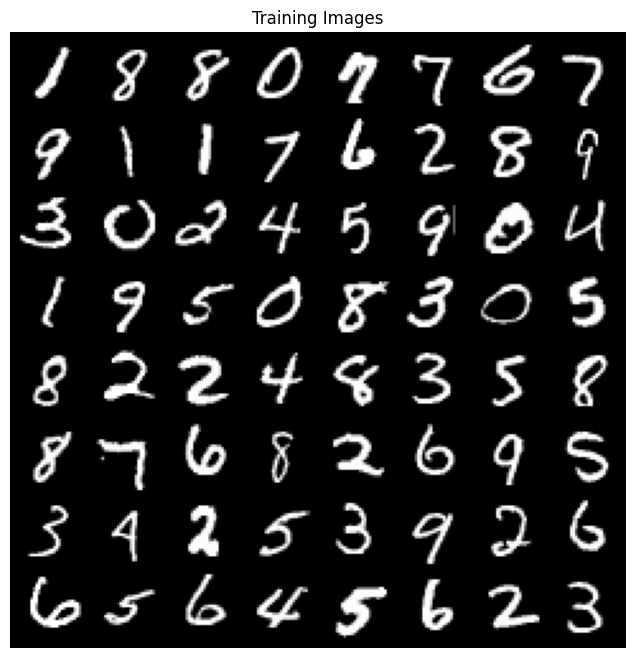

In [ ]:
# Vorbereiten und einlesen der Daten
# Transformationen: Skalierung auf image_size, Umwandlung in Tensor, Normalisierung auf [-1, 1]
# Am Beispiel für den MNIST Datensatz:
transform = transforms.Compose(
    [
        transforms.Resize(image_size),  # Bilder skalieren falls nicht einheitlich
        transforms.ToTensor(),  # Bilder in PyTorch Tensor umwandeln)
        transforms.Normalize(
            (0.5,), (0.5,)
        ),  # Normalisiert auf [-1, 1] (Mittelwert 0.5, Std.abw. 0.5 für einen Kanal)
    ]
)

# Laden des Trainings-Datensatzes
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)

# DataLoader für das Training
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

print(f"Anzahl der Trainingsbilder: {len(train_dataset)}")
print(
    f"Größe eines transformierten Bildes: {image_size}x{image_size} Pixel mit {num_channels} Kanal(en)"
)

# Darstellung einiger Trainingsbilder
real_batch = next(iter(train_loader))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(
    np.transpose(
        vutils.make_grid(
            real_batch[0].to(device)[:64], padding=2, normalize=True
        ).cpu(),
        (1, 2, 0),
    )
)
plt.show()


### Generator definieren 

In [ ]:
# erstelle ein einfaches Netz, das aus Rauschen Bilder erstellt
class Generator(nn.Module):
    def __init__(self, latent_dim, output_size, **kwargs):
        super().__init__()
        # Schichten können direkt über Sequential in eine Art Pipeline gebracht werden
        self.layers = nn.Sequential(
            # bestimme welche Layer/Normalisierungen/Aktivierungsfunktionen verwendet werden sollen

        )

    def forward(self, x):
        return self.layers(x)

#### Diskriminator definieren

In [ ]:
# Zweites Netz erstellen, dass die erstellten Bilder und echte Bilder bewertet
class Discriminator(nn.Module):
    def __init__(self, input_size, **kwargs):
        super().__init__()
        self.layers = nn.Sequential(
        )

    def forward(self, x):
        return self.layers(x)

#### Instanzen der Netze erstellen

In [1]:
# Erstellen der Instanzen mit den Hyperparametern
# Zeigen der Netzarchitekturen

### Verlustfunktion und Optimierer

In [ ]:
# Verlustfunktion für das Training (zb Binary Cross-Entropy Loss)


# Labels für echtes und gefälschtes Training
# real_label =
# fake_label =

# Optimierer für G und D (zB Adam)

### Training des GANs

In [ ]:
# Liste zur Speicherung von Trainingsstatistiken
img_list = []  # Zum Speichern von Beispielbildern, die vom Generator erstellt wurden
G_losses = []  # Generator-Verluste
D_losses = []  # Diskriminator-Verluste

# feste Rauschvektoren könnten festgelegt werden um den Fortschritt des GANs nach jeder Epoche zu sehen

print("Starte GAN Training...")
for epoch in range(num_epochs):
    for i, data in enumerate(train_loader):
        # ------ Vorbereiten der Daten --------
        # Labeln der realen Bilder
        # Format verifizieren (je nach Netz, sollen sie 1D sein?)


        # ------ 1. Trainieren des Diskriminators --------
        # Trainieren des Diskriminators mit realen Bildern

        # Trainiere mit "gefälschten" Bildern
        # Erstellen der Bilder
        # Diskriminator-Ausgabe für gefälschte Bilder (detach, damit G nicht aktualisiert wird)

        # Fehlerberechnung der gefälschten Bilder

        # ------ 2. Trainieren des Generators -------
        # Bilder erstellen und danach in den Diskriminator
        # Fehler und Backpropagation

        # --- 3. Fehler speichern und Fortschritt ausgeben ---


    # Optional: Erstellen der Fake Bilder nach jeder Epoche
    with torch.no_grad():
        fake_images_for_viz = netG(fixed_noise).detach().cpu()

        img_list.append(fake_images_for_viz)

print("GAN Training beendet.")


Starte GAN Training...
[1/50][0/469]	Loss_D: 1.4118	Loss_G: 0.6864	D(x): 0.4936	D(G(z))_before_G: 0.5062	D(G(z))_after_G: 0.5034
[1/50][200/469]	Loss_D: 1.4376	Loss_G: 0.5515	D(x): 0.4658	D(G(z))_before_G: 0.4744	D(G(z))_after_G: 0.5788
[1/50][400/469]	Loss_D: 0.9835	Loss_G: 1.4938	D(x): 0.8184	D(G(z))_before_G: 0.5352	D(G(z))_after_G: 0.2289
[2/50][0/469]	Loss_D: 1.0715	Loss_G: 0.4996	D(x): 0.4746	D(G(z))_before_G: 0.2284	D(G(z))_after_G: 0.6183
[2/50][200/469]	Loss_D: 0.8116	Loss_G: 1.1376	D(x): 0.6088	D(G(z))_before_G: 0.2313	D(G(z))_after_G: 0.3308
[2/50][400/469]	Loss_D: 0.8921	Loss_G: 0.8915	D(x): 0.5268	D(G(z))_before_G: 0.1672	D(G(z))_after_G: 0.4255
[3/50][0/469]	Loss_D: 1.0152	Loss_G: 0.2974	D(x): 0.4740	D(G(z))_before_G: 0.1449	D(G(z))_after_G: 0.7468
[3/50][200/469]	Loss_D: 0.8494	Loss_G: 0.7739	D(x): 0.5556	D(G(z))_before_G: 0.1444	D(G(z))_after_G: 0.4819
[3/50][400/469]	Loss_D: 0.6579	Loss_G: 1.5447	D(x): 0.7322	D(G(z))_before_G: 0.2508	D(G(z))_after_G: 0.2368
[4/50][0/46

### Visualisierung

In [2]:
# Plot der Generator- und Diskriminator-Verluste über Iteration oder Epochen

In [3]:
# Visualisierung der generierten Bilder vs reale Bilder
